In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Loan_dataset = pd.read_csv("C:/Users/sunda/Desktop/PORTFOLIO/FINANCE- loan prediction/cleaned SQL loan dataset.csv")

In [5]:
Loan_dataset.head(10)

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0,128000,360,1,Urban,Yes
1,Male,Yes,1,Graduate,No,4583,1508,128000,360,1,Rural,No
2,Male,Yes,0,Graduate,Yes,3000,0,66000,360,1,Urban,Yes
3,Male,Yes,0,Not Graduate,No,2583,2358,120000,360,1,Urban,Yes
4,Male,No,0,Graduate,No,6000,0,141000,360,1,Urban,Yes
5,Male,Yes,2,Graduate,Yes,5417,4196,267000,360,1,Urban,Yes
6,Male,Yes,0,Not Graduate,No,2333,1516,95000,360,1,Urban,Yes
7,Male,Yes,3,Graduate,No,3036,2504,158000,360,0,Semiurban,No
8,Male,Yes,2,Graduate,No,4006,1526,168000,360,1,Urban,Yes
9,Male,Yes,1,Graduate,No,12841,10968,349000,360,1,Semiurban,No


In [6]:
Loan_dataset['Total_household_income'] = Loan_dataset['Applicant_Income'] + Loan_dataset['Coapplicant_Income']

In [7]:
Loan_dataset['Debt_to_income_ratio'] = (Loan_dataset['Loan_Amount'] / Loan_dataset['Total_household_income']).round(2)

In [8]:
Loan_dataset.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Total_household_income', 'Debt_to_income_ratio'],
      dtype='object')

In [9]:
Loan_dataset['Recommendation'] = 'Reject'
Loan_dataset.loc[(Loan_dataset['Credit_History'] == 1), 'Recommendation'] = 'Approve'
Loan_dataset.loc[(Loan_dataset['Credit_History'] == 0) & (Loan_dataset['Total_household_income'] >= 8000), 'Recommendation'] = 'Review'

In [10]:
Loan_dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_household_income,Debt_to_income_ratio,Recommendation
0,Male,No,0,Graduate,No,5849,0,128000,360,1,Urban,Yes,5849,21.88,Approve
1,Male,Yes,1,Graduate,No,4583,1508,128000,360,1,Rural,No,6091,21.01,Approve
2,Male,Yes,0,Graduate,Yes,3000,0,66000,360,1,Urban,Yes,3000,22.00,Approve
3,Male,Yes,0,Not Graduate,No,2583,2358,120000,360,1,Urban,Yes,4941,24.29,Approve
4,Male,No,0,Graduate,No,6000,0,141000,360,1,Urban,Yes,6000,23.50,Approve


In [11]:
##STATISTICAL ANALYSIS 

correllation = Loan_dataset[['Total_household_income','Loan_Amount', 'Debt_to_income_ratio', 'Credit_History']].corr()
print(correllation)

                        Total_household_income  Loan_Amount  \
Total_household_income                1.000000     0.620316   
Loan_Amount                           0.620316     1.000000   
Debt_to_income_ratio                 -0.391412     0.152816   
Credit_History                       -0.020031    -0.034473   

                        Debt_to_income_ratio  Credit_History  
Total_household_income             -0.391412       -0.020031  
Loan_Amount                         0.152816       -0.034473  
Debt_to_income_ratio                1.000000       -0.046803  
Credit_History                     -0.046803        1.000000  


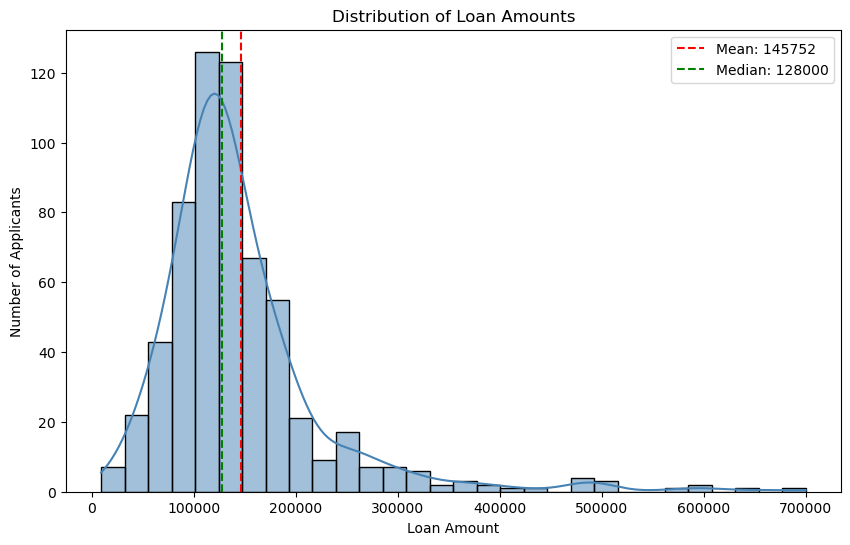

In [12]:
##DISTRIBUTION OF LOAN AMOUNT.

plt.figure(figsize=(10, 6))
sns.histplot(Loan_dataset['Loan_Amount'], bins=30, kde=True, color='steelblue')
plt.axvline(Loan_dataset['Loan_Amount'].mean(), color='red', linestyle='--', label=f"Mean: {Loan_dataset['Loan_Amount'].mean():.0f}")
plt.axvline(Loan_dataset['Loan_Amount'].median(), color='green', linestyle='--', label=f"Median: {Loan_dataset['Loan_Amount'].median():.0f}")
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Applicants')
plt.legend()
plt.savefig('Distribution_of_loan_Amount.png')
plt.show()


In [13]:
                                                        ## VISUALISATIONS 

C:\Users\sunda\AppData\Local\Temp\ipykernel_8860\1276015670.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = Approval_by_credit, x='Credit_History_txt', y ='Approval_Rate', palette='coolwarm')


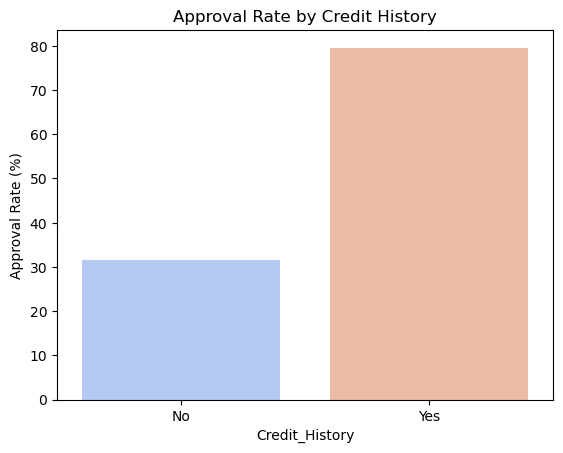

In [19]:
##APPROVAL RATE BY CREDIT HISTORY
Loan_dataset['Credit_History_txt'] = Loan_dataset["Credit_History"].replace({1: 'Yes', 0:'No'})
Approval_by_credit = Loan_dataset.groupby('Credit_History_txt')['Loan_Status'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).round(2).reset_index() 
## lambda let you divide column 'inputs/value' and 
##[len(x) means sum( all yes) / count of 'yes' x 100]


Approval_by_credit.columns = ['Credit_History_txt', 'Approval_Rate'] ## renames the groupded column output


sns.barplot(data = Approval_by_credit, x='Credit_History_txt', y ='Approval_Rate', palette='coolwarm')
plt.title('Approval Rate by Credit History')
plt.xlabel('Credit_History')
plt.ylabel('Approval Rate (%)')
plt.savefig('Approval_by_credit_history.png')
plt.show()

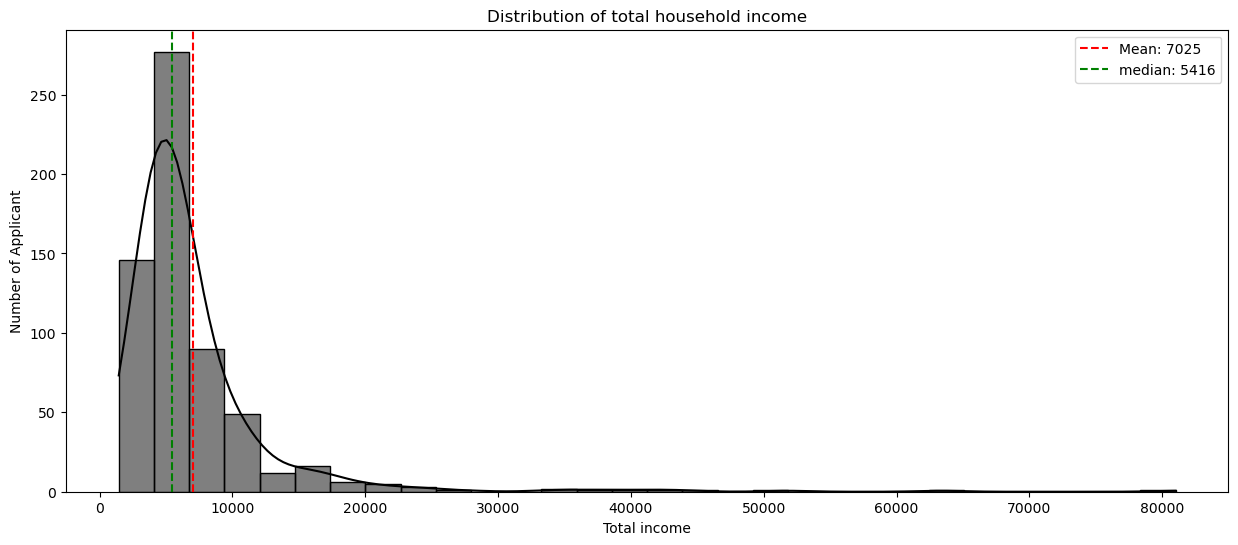

In [20]:
##INCOME DISTRIBUTION

plt.figure(figsize=(15,6))
sns.histplot(Loan_dataset['Total_household_income'], bins=30, kde=True, color='black')
plt.axvline(Loan_dataset['Total_household_income'].mean(), color='red', linestyle='--', 
            label= f"Mean: {Loan_dataset['Total_household_income'].mean():.0f}")
plt.axvline(Loan_dataset['Total_household_income'].median(), color='green', linestyle='--', 
            label=f"median: {Loan_dataset['Total_household_income'].median():.0f}")
plt.title('Distribution of total household income')
plt.xlabel('Total income')
plt.ylabel('Number of Applicant')
plt.legend()
plt.savefig('Distribution_of_household_income.png')
plt.show()

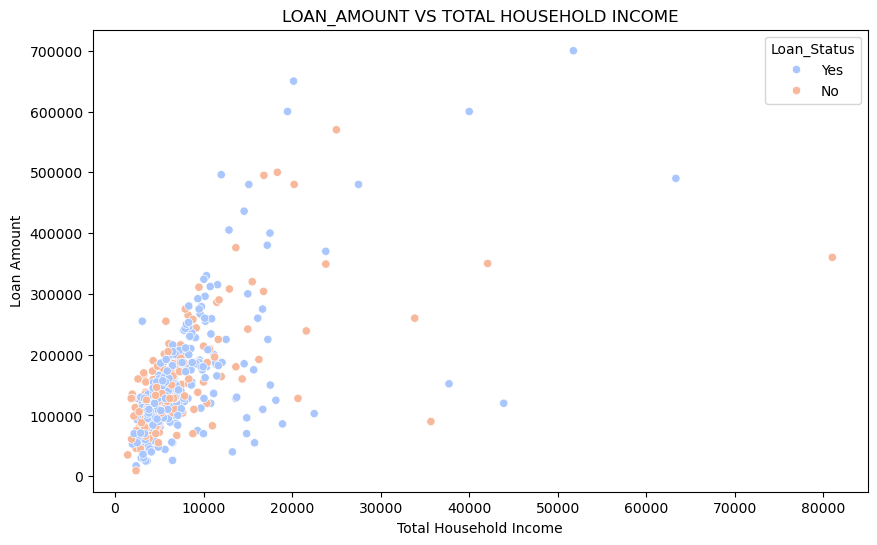

In [21]:
##LOAN AMOUNT VS TOTAL HOUSEHOLD INCOME 
plt.figure(figsize=(10,6))
sns.scatterplot(data = Loan_dataset, x ='Total_household_income', y= 'Loan_Amount' , hue='Loan_Status', palette='coolwarm')
plt.title('LOAN_AMOUNT VS TOTAL HOUSEHOLD INCOME')
plt.xlabel('Total Household Income')
plt.ylabel('Loan Amount')
plt.legend(title='Loan_Status')
plt.savefig('loan_Amount_VS_total_income.png')
plt.show()

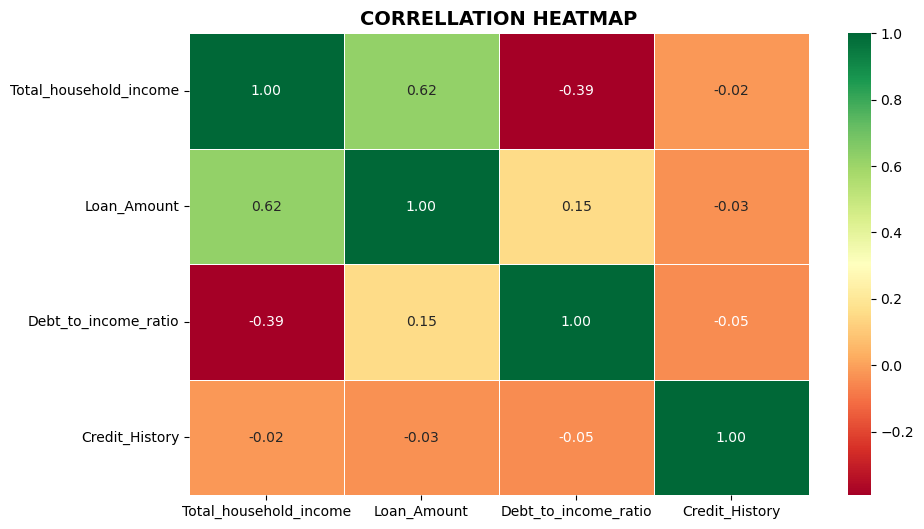

In [22]:
##CORRELATION HEATMAP

plt.figure(figsize=(10,6))
corr= Loan_dataset[['Total_household_income', 'Loan_Amount', 'Debt_to_income_ratio',
                    'Credit_History']].corr()
sns.heatmap(corr, annot= True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('CORRELLATION HEATMAP', fontsize=14, fontweight='bold')
plt.savefig('Correllation_heatmap.png')
plt.show()

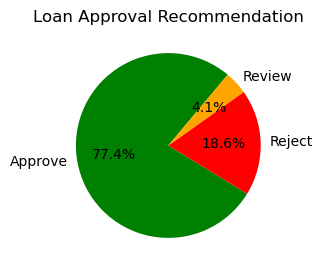

In [23]:
##APPROVAL RECOMEDATIONS


Recommendation_counts = Loan_dataset['Recommendation'].value_counts()
plt.figure(figsize=(5,3))
plt.pie(Recommendation_counts, labels= Recommendation_counts.index,
        autopct='%1.1f%%', 
        colors=['green', 'Red', 'Orange'],
        startangle=50)
plt.title('Loan Approval Recommendation')
plt.savefig('Loan Approval Recommnedation.png')
plt.show()